Class implementation for CAX simulation module

```26/05/2026```

What do I need to accomplish? I need to be able to simulate the passage of light through the CAX beamline, from source through slits to DVF screen. I then need to be able to extract the resulting image at a given $y$ position (optical axis). Then I need to perform movements to the mirror and regenerate the image.

To create a general `CAXSim` class, I'll first write a basic `OpticalElement` wrapper class for Shadow OEs, then I'll create children with more specific methods, all the way to a `BeamLine` class that possesses the necessary attributes and methods to perform simulations and modify the system. 

In [1]:
!which python

/home/gabriel.amici/miniconda3/bin/python


In [2]:
import os
import sys

sys.path.append(os.path.expanduser("~/repos/cax-scripts"))


In [ ]:
import Shadow
from shadowpy.optical_elements import ToroidalMirror, Slits, Screen
from shadowpy.sources import BendingMagnet
from shadowpy.beamline import BeamLine
from shadowpy.utils import rotation_matrix, ReferenceFrame
from optlnls.shadow import run_shadow_caustic, get_good_ranges, read_caustic, plot_caustic

import numpy as np
import matplotlib.pyplot as plt

In [38]:
# CAX Optical Elements
source = BendingMagnet("B1", "source.props")
mirror = ToroidalMirror("M1", "mirror.props")
slit   = Slits("Slit_A1", "slits.props")
screen = Screen("DVF_B1", "screen.props")

optical_elements = [mirror, slit, screen]

# Frames of reference
sirius_frame = ReferenceFrame(name="sirius")

R1 = rotation_matrix('x', 90)
R2 = rotation_matrix('y', 180)
source_R = R1 @ R2

shadow_frame = sirius_frame.child_frame(relative_origin=[0, 0, 0], 
                                        relative_rotation=source_R, 
                                        name="shadow")

beam = Shadow.Beam()
cax  = BeamLine(name="CAX", source=source, optical_elements=optical_elements,
               beamline_frame=shadow_frame, lab_frame=sirius_frame, beam=beam)

 Generated        50000  rays out of      1000000
                 100000
                 150000
                 200000
                 250000
                 300000
                 350000
                 400000
                 450000
                 500000
                 550000
                 600000
                 650000
                 700000
                 750000
                 800000
                 850000
                 900000
                 950000
                1000000
 Exit from SOURCE


In [39]:
cax.trace()

 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC


/home/gabriel.amici/repos/cax-scripts/caxscripts/image_statistics.py:246: UserWarning: Beam not visible; skipping quick analysis.
  warnings.warn("Beam not visible; skipping quick analysis.")


 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC


No parameters provided; using the calculated from moments.


(<Figure size 1000x600 with 2 Axes>,
 <AxesSubplot:title={'center':'2D Histogram with Ellipses'}, xlabel='x', ylabel='y'>)

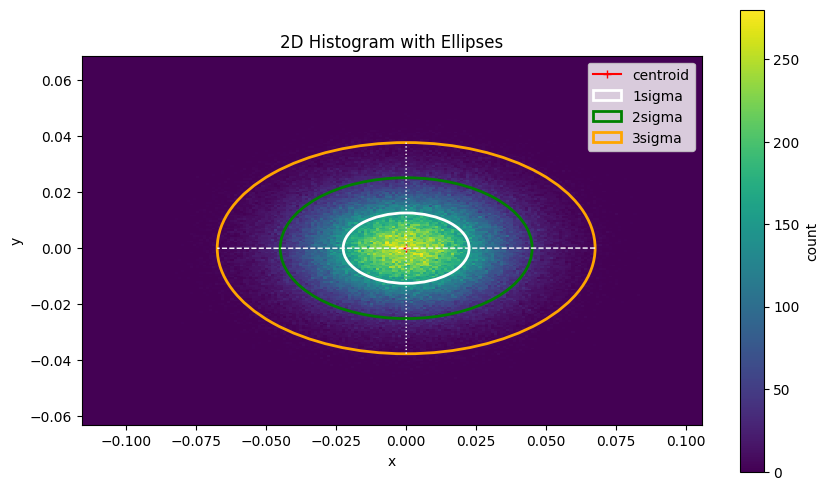

In [40]:
screen.image.plot()

In [ ]:
focus = cax.beams[-1]
x = screen.image.xcenters
y = screen.image.ycenters

beam2D = np.zeros((len(y)+1, len(x)+1))
beam2D[0,1:] = x
beam2D[1:,0] = y
beam2D[1:,1:] = screen.image.img


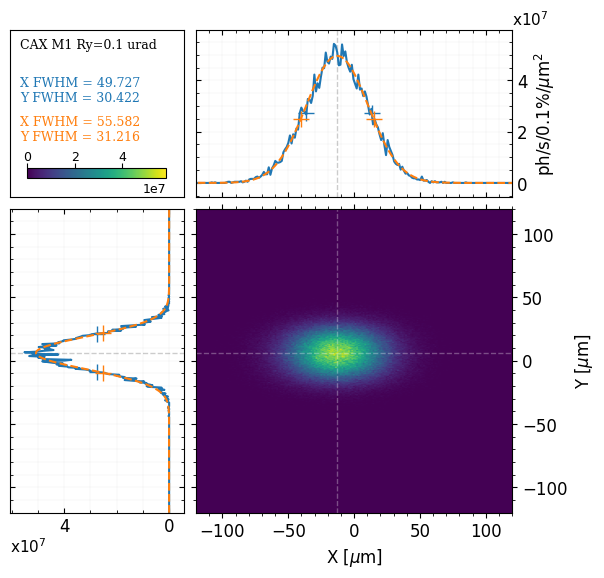

{'rms_x': 23.78745662349663,
 'rms_z': 12.749925508693504,
 'fwhm_x': 49.72660261373139,
 'fwhm_z': 30.42199968501729,
 'fwhm_x_coords': [-36.24857023635177,
  13.478032377379622,
  2.7112545089120883,
  2.711262108664242],
 'fwhm_z_coords': [-8.944835493079824,
  21.477164191937465,
  2.756423738532791,
  2.756443456808648],
 'integral': 100000000000.0,
 'mean_x': -13.154466875429781,
 'mean_z': 6.261583536704013,
 'cut_coord_x': -12.85050421303957,
 'cut_coord_z': 6.06249216357782,
 'peak_value': 58743496.11897539,
 'min_value': 0.0,
 'x_axis': array([-378.79493959, -377.55864082, -376.32234205, -375.08604328,
        -373.84974451, -372.61344574, -371.37714698, -370.14084821,
        -368.90454944, -367.66825067, -366.4319519 , -365.19565314,
        -363.95935437, -362.7230556 , -361.48675683, -360.25045806,
        -359.0141593 , -357.77786053, -356.54156176, -355.30526299,
        -354.06896422, -352.83266545, -351.59636669, -350.36006792,
        -349.12376915, -347.88747038, -3

In [37]:
from optlnls.plot import plot_beam

plot_beam(beam2D, cut=3, textA=1, textB=5, textC=10, textD=0, fitType=1,
          x_range=1, y_range=1, plot_title='CAX M1 Ry=0.1 urad', show_colorbar=1,
          x_range_min=-0.12, x_range_max=0.12, y_range_min=-0.12, y_range_max=0.12,
          zero_pad_x=1, zero_pad_y=1, cmap='viridis', integral=1e11,
          units=2)


No parameters provided; using the calculated from moments.


(<Figure size 1000x600 with 2 Axes>,
 <AxesSubplot:title={'center':'2D Histogram with Ellipses'}, xlabel='x', ylabel='y'>)

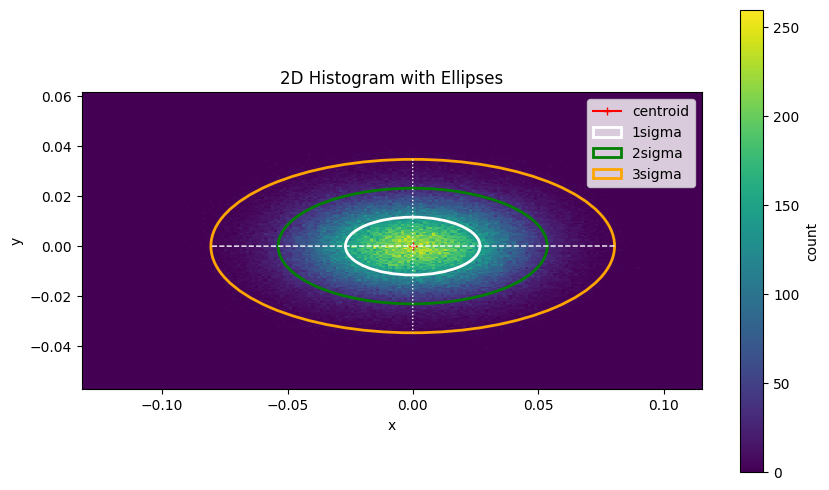

In [16]:
screen.image.plot()

In [7]:
source.image.print_stats(hprm=source.image.hprm_fit)

centroid   = (1.0172e-04, 8.2557e-06)
sigma x    = 1.9860e-02
sigma y    = 1.1501e-02
fwhm x     = 4.6766e-02
fwhm y     = 2.7082e-02
xy cov     = 3.9085e-07

principal sigmas:
    sigma minor = 0.011500571840645431
    sigma major = 0.019859548065942208

theta = 1.4910e-03 rad = 8.5427e-02 deg

cov matrix:
[[3.94401067e-04 3.90845199e-07]
 [3.90845199e-07 1.32263735e-04]]


In [12]:
screen.image.print_stats(hprm=screen.image.hprm_fit)

centroid   = (1.3694e-04, -2.6131e-05)
sigma x    = 2.7769e-02
sigma y    = 1.1443e-02
fwhm x     = 6.5392e-02
fwhm y     = 2.6947e-02
xy cov     = -6.1604e-09

principal sigmas:
    sigma minor = 0.011443373801334275
    sigma major = 0.027769485137542405

theta = -9.6227e-06 rad = -5.5134e-04 deg

cov matrix:
[[ 7.71144305e-04 -6.16036456e-09]
 [-6.16036456e-09  1.30950804e-04]]


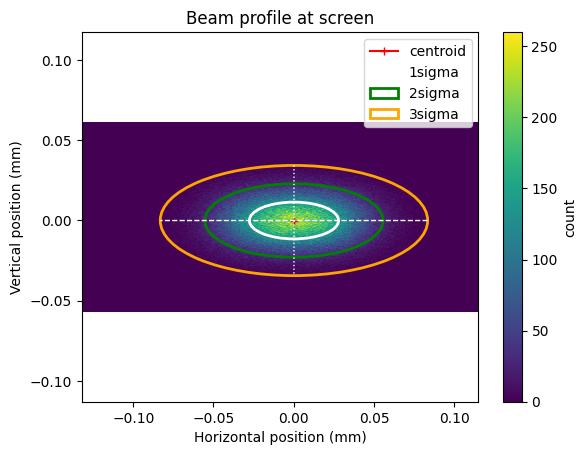

In [11]:
fig, ax = plt.subplots()
fig, ax = screen.image.plot(hprm=screen.image.hprm_fit, fig=fig, ax=ax)
ax.set_xlabel("Horizontal position (mm)")
ax.set_ylabel("Vertical position (mm)")
ax.set_title("Beam profile at screen")
# plt.colorbar(label="Intensity (a.u.)")
plt.axis('equal')
plt.show()

In [9]:
mirror.offset

array([0., 0., 0.])

In [10]:
mirror.offset = [1, 0, 0]

 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to I

In [ ]:
# tx scan
tx = np.linspace(-3, 3, 11)
fwhm_x = np.array([])
fwhm_y = np.array([])

In [ ]:
ry = np.linspace(2, 3, 11)*1e-3 #mrad
fwhm_x = np.array([])
fwhm_y = np.array([])
mu_x   = np.array([])
mu_y   = np.array([])

In [ ]:
for ry_i in ry:
    mirror.tilt = [0, ry_i, 0]
    ax.clear()
    
    fig, ax = screen.image.plot(hprm=screen.image.hprm_fit, colorbar=False, fig=fig, ax=ax)
    np.append(fwhm_x, screen.image.hprm_fit['fwhmx'])
    np.append(fwhm_y, screen.image.hprm_fit['fwhmy'])
    np.append(mu_x, screen.image.hprm_fit['mux'])
    np.append(mu_y, screen.image.hprm_fit['muy'])
    # ax.set_xlim(-0.1, 0.1)
    # ax.set_ylim(-0.06, 0.06)
    clear_output(wait=True)
    display(fig)

In [ ]:
mirror.offset = np.array([-0.20977, -1.90443, 0])
mirror.tilt = np.array([-2.04134, 1.56847, 4.26974])*1.e-3

In [ ]:
screen.image.plot()

In [ ]:
ry

In [ ]:
for tx_i in tx:
    mirror.offset = [tx_i, 0, 0]
    ax.clear()
    
    fig, ax = screen.image.plot(hprm=screen.image.hprm_fit, colorbar=False, fig=fig, ax=ax)
    fwhm_x.append(screen.image.hprm_fit['fwhmx'])
    fwhm_y.append(screen.image.hprm_fit['fwhmy'])
    ax.set_xlim(-0.1, 0.1)
    ax.set_ylim(-0.06, 0.06)
    clear_output(wait=True)
    display(fig)

In [ ]:
plt.ioff()

In [ ]:
plt.plot(tx, fwhm_x, label='FWHM X')
plt.plot(tx, fwhm_y, label='FWHM Y')
plt.xlabel('Mirror Tx (mm)')
plt.ylabel('FWHM (μm)')
plt.title('FWHM vs Mirror Tx')
# plt.ylim(0.025, 0.03)
plt.legend()
plt.show()

In [ ]:
plt.show()

In [ ]:
plt.ion()

fig, ax = plt.subplots()
fig, ax = screen.image.plot(hprm=screen.image.hprm_fit, fig=fig, ax=ax)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

ticket = screen.image

plt.pcolormesh(ticket["bin_h_edges"], ticket["bin_v_edges"], ticket["histogram"].T)
plt.xlabel("Horizontal position (mm)")
plt.ylabel("Vertical position (mm)")
plt.title("Beam profile at screen")
plt.colorbar(label="Intensity (a.u.)")
plt.axis('equal')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

ticket = screen.image

plt.pcolormesh(ticket["bin_h_edges"], ticket["bin_v_edges"], ticket["histogram"].T)
plt.xlabel("Horizontal position (mm)")
plt.ylabel("Vertical position (mm)")
plt.title("Beam profile at screen")
plt.colorbar(label="Intensity (a.u.)")
plt.axis('equal')
plt.show()

In [ ]:
print(f"Horizontal FWHM: \t{screen.image['fwhm_h']*1000:.6f} μm")
print(f"Vertical FWHM:   \t{screen.image['fwhm_v']*1000:.6f} μm")

In [ ]:
print(f"Horizontal FWHM: \t{screen.image['fwhm_h']*1000:.6f} μm")
print(f"Vertical FWHM:   \t{screen.image['fwhm_v']*1000:.6f} μm")

In [ ]:
print(f"Horizontal FWHM: \t{screen.image['fwhm_h']*1000:.6f} μm")
print(f"Vertical FWHM:   \t{screen.image['fwhm_v']*1000:.6f} μm")

In [ ]:
screen.shadow_oe.IDUMMY

In [ ]:
screen.reset()

In [ ]:
mirror.offset

In [ ]:
mirror.offset = [1.4, 0, 0]

In [ ]:
mirror.offset

In [ ]:
mirror.image

In [ ]:
len(cax.beams)

In [ ]:
Shadow.ShadowTools.plotxy(cax.beams[3],1,3,nbins=100, nolost=1,title="Real space")


In [ ]:
Shadow.ShadowTools.plotxy(cax.beams[3],1,3,nbins=101,nolost=1,title="Real space")


In [ ]:
test_beam = cax.beams[3].duplicate()

In [ ]:
Shadow.ShadowTools.plotxy(test_beam,1,3,nbins=101,nolost=1,title="Real space")


In [ ]:
retraced_beam = test_beam.duplicate()

In [ ]:
retraced_beam.retrace(0)

In [ ]:
Shadow.ShadowTools.plotxy(retraced_beam,1,3,nbins=101,nolost=1,title="Real space")

In [ ]:
import numpy as np

In [ ]:
screen.image["histogram"].shape

In [ ]:
# Caustic
fwhm_x = []
fwhm_y = []

distances = np.linspace(-500, 100, 50)

for dist in distances:
    retraced_beam.retrace(dist)
    ticket = retraced_beam.histo2(col_h=3, col_v=1, nbins=150, nolost=1)
    fwhm_x.append(ticket['fwhm_h'])
    fwhm_y.append(ticket['fwhm_v'])



In [ ]:
plt.plot(distances, np.array(fwhm_x), label='Horizontal FWHM')
plt.plot(distances, np.array(fwhm_y), label='Vertical FWHM')
plt.xlabel('Distance from screen (mm)')
plt.ylabel('FWHM (μm)')
plt.title('Caustic of the beam')
plt.legend()
plt.grid()
plt.show()

In [ ]:
screen.shadow_oe.OFFY = -100

In [ ]:
screen.offset

In [ ]:
import sys
import os

sys.path.append(os.path.expanduser("~/repos/cax-scripts"))
# sys.path.append(os.path.expanduser("~/repos/dev_packages/siriuspy/siriuspy"))


In [ ]:
from caxscripts.image_statistics import Histogram2DAnalyzer

In [ ]:
ticket = screen.image
hist = ticket["histogram"]
bin_h_edges = ticket["bin_h_edges"]
bin_v_edges = ticket["bin_v_edges"]

ana = Histogram2DAnalyzer(img=hist, xedges=bin_h_edges, yedges=bin_v_edges)
ana.fit()

In [ ]:
ana.plot(hprm=ana.hprm_fit)

In [ ]:
ana.compute_quick()

In [ ]:
cx, cy = ana._qck_centroid()

droi = 4
img = ana.img
roi_avg = np.mean(img[cx - droi:cx + droi, cy - droi:cy + droi]
)
mean = np.mean(img)
ratio = roi_avg / mean if mean != 0 else 0
ratio >= 10

In [ ]:
roi_avg

In [ ]:
mean

In [ ]:
ratio

In [ ]:
cx

In [ ]:
roi_avg

In [ ]:
ana.hprm_mom['fwhmy']

In [ ]:
import matplotlib.pyplot as plt

ticket = screen.image

plt.pcolormesh(ticket["bin_h_edges"], ticket["bin_v_edges"], ticket["histogram"].T)
plt.xlabel("Horizontal position (mm)")
plt.ylabel("Vertical position (mm)")
plt.title("Beam profile at screen")
plt.colorbar(label="Intensity (a.u.)")
plt.axis('equal')
plt.show()

In [ ]:
cax.beam.retrace(12641)

In [ ]:
Shadow.ShadowTools.plotxy(cax.beam,1,3,nbins=101,nolost=1,title="Real space")


In [ ]:
cax.elements[1].frame

In [ ]:
mirror.offset

In [ ]:
mirror.offset = [0.1, 0.2, 0.3]

In [ ]:
source_x_vec = np.array([1, 0, 0])
source_y_vec = np.array([0, 1, 0])
source_z_vec = np.array([0, 0, 1])


In [ ]:
shadow_source_frame.vector_to_lab(source_z_vec)

In [ ]:
mirror_R = rot_matrix('y', -np.pi/2)

In [ ]:
shadow_mirror_frame = shadow_source_frame.child_frame(relative_origin=[0, 17000, 0],
                                                      relative_rotation=mirror_R,
                                                      name="shadow_mirror")

In [ ]:
mirror_x_vec = np.eye(3)[0]
mirror_y_vec = np.eye(3)[1]
mirror_z_vec = np.eye(3)[2]


In [ ]:
print(f"Mirror X vector in lab frame: {np.round(shadow_mirror_frame.vector_to_lab(mirror_x_vec))}")
print(f"Mirror Y vector in lab frame: {np.round(shadow_mirror_frame.vector_to_lab(mirror_y_vec))}")
print(f"Mirror Z vector in lab frame: {np.round(shadow_mirror_frame.vector_to_lab(mirror_z_vec))}")

In [ ]:
shadow_screens_frame = shadow_mirror_frame.child_frame(relative_origin=[0, 4359, 0],
                                                      relative_rotation=np.eye(3),
                                                      name="shadow_screen")

In [ ]:
np.round(shadow_screens_frame.point_to_lab(shadow_screens_frame.origin)[2]+12641)